In [1]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sys.path.append(os.path.abspath("../src"))

%reload_ext autoreload
%autoreload 2

from postgres_connection import connection

# Data loading

In [94]:
df_train = connection("dwh.application_train")
df_test = connection("dwh.application_test")
bureau = connection("dwh.bureau")
bureau_balance = connection("dwh.bureau_balance")
df_description = connection("dwh.homecredit_columns_description;")
credit_card_balance = connection("dwh.credit_card_balance")

# Check the data

## Data model

![Data model](home_credit.png)


Мы решаем задачу скоринга для банка Home Credit. Специфика банка заключается в клиентской базе - в основном они предлагают кредиты для людей, не имеющих кредитной истории. 
Из картинки выше, мы понимаем, что у нас есть три основные таблицы: кредитное бюро, приложение, предыдущее приложение. Давайте рассмотрим две из них - бюро и приложение.

## Glimpse the data

In [13]:
df_train.sample(5)

,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,region_population_relative,days_birth,days_employed,days_registration,days_id_publish,own_car_age,flag_mobil,flag_emp_phone,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,occupation_type,cnt_fam_members,region_rating_client,region_rating_client_w_city,weekday_appr_process_start,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,reg_city_not_live_city,reg_city_not_work_city,live_city_not_work_city,organization_type,ext_source_1,ext_source_2,ext_source_3,apartments_avg,basementarea_avg,years_beginexpluatation_avg,years_build_avg,commonarea_avg,elevators_avg,entrances_avg,floorsmax_avg,floorsmin_avg,landarea_avg,livingapartments_avg,livingarea_avg,nonlivingapartments_avg,nonlivingarea_avg,apartments_mode,basementarea_mode,years_beginexpluatation_mode,years_build_mode,commonarea_mode,elevators_mode,entrances_mode,floorsmax_mode,floorsmin_mode,landarea_mode,livingapartments_mode,livingarea_mode,nonlivingapartments_mode,nonlivingarea_mode,apartments_medi,basementarea_medi,years_beginexpluatation_medi,years_build_medi,commonarea_medi,elevators_medi,entrances_medi,floorsmax_medi,floorsmin_medi,landarea_medi,livingapartments_medi,livingarea_medi,nonlivingapartments_medi,nonlivingarea_medi,fondkapremont_mode,housetype_mode,totalarea_mode,wallsmaterial_mode,emergencystate_mode,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,days_last_phone_change,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
21667,268272,0,Cash loans,F,N,Y,1,229500.0,1312110.0,55593.0,1125000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018801,-16359,-3936,-788.0,-4844,NaN,1,1,1,1,0,0,Accountants,3.0,2,2,MONDAY,6,0,0,0,0,0,0,Business Entity Type 1,0.865483,0.558982,0.382502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN,,,5.0,2.0,5.0,0.0,-1663.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0
235765,159888,0,Cash loans,F,N,Y,1,225000.0,1125000.0,33025.5,1125000.0,Unaccompanied,State servant,Higher education,Married,House / apartment,0.026392,-15335,-189,-399.0,-4040,NaN,1,1,0,1,0,0,Accountants,3.0,2,2,TUESDAY,17,0,0,0,0,1,1,School,NaN,0.705548,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN,,,1.0,0.0,1.0,0.0,-2255.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
222153,144116,0,Cash loans,F,N,Y,0,112500.0,270000.0,27796.5,270000.0,Unaccompanied,Pensioner,Secondary / secondary special,Married,House / apartment,0.020246,-23697,365243,-9477.0,-4213,NaN,1,0,0,1,1,0,,2.0,3,3,MONDAY,16,0,0,0,0,0,0,XNA,NaN,0.062226,0.785052,NaN,NaN,NaN,NaN,NaN,NaN,0.069,NaN,NaN,NaN,NaN,0.0758,NaN,0.0418,NaN,NaN,NaN,NaN,NaN,NaN,0.069,NaN,NaN,NaN,NaN,0.0789,NaN,0.0443,NaN,NaN,NaN,NaN,NaN,NaN,0.069,NaN,NaN,NaN,NaN,0.0771,NaN,0.0427,,,0.0687,,No,0.0,0.0,0.0,0.0,-1742.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,4.0
16087,261786,0,Cash loans,F,N,Y,0,220500.0,273024.0,8406.0,216000.0,Unaccompanied,Pensioner,Secondary / secondary special,Separated,House / apartment,0.072508,-21225,365243,-12503

In [92]:
df_train.describe()

,sk_id_curr,target,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,region_population_relative,days_birth,days_employed,days_registration,days_id_publish,own_car_age,flag_mobil,flag_emp_phone,flag_work_phone,flag_cont_mobile,flag_phone,flag_email,cnt_fam_members,region_rating_client,region_rating_client_w_city,hour_appr_process_start,reg_region_not_live_region,reg_region_not_work_region,live_region_not_work_region,reg_city_not_live_city,reg_city_not_work_city,live_city_not_work_city,ext_source_1,ext_source_2,ext_source_3,apartments_avg,basementarea_avg,years_beginexpluatation_avg,years_build_avg,commonarea_avg,elevators_avg,entrances_avg,floorsmax_avg,floorsmin_avg,landarea_avg,livingapartments_avg,livingarea_avg,nonlivingapartments_avg,nonlivingarea_avg,apartments_mode,basementarea_mode,years_beginexpluatation_mode,years_build_mode,commonarea_mode,elevators_mode,entrances_mode,floorsmax_mode,floorsmin_mode,landarea_mode,livingapartments_mode,livingarea_mode,nonlivingapartments_mode,nonlivingarea_mode,apartments_medi,basementarea_medi,years_beginexpluatation_medi,years_build_medi,commonarea_medi,elevators_medi,entrances_medi,floorsmax_medi,floorsmin_medi,landarea_medi,livingapartments_medi,livingarea_medi,nonlivingapartments_medi,nonlivingarea_medi,totalarea_mode,obs_30_cnt_social_circle,def_30_cnt_social_circle,obs_60_cnt_social_circle,def_60_cnt_social_circle,days_last_phone_change,flag_document_2,flag_document_3,flag_document_4,flag_document_5,flag_document_6,flag_document_7,flag_document_8,flag_document_9,flag_document_10,flag_document_11,flag_document_12,flag_document_13,flag_document_14,flag_document_15,flag_document_16,flag_document_17,flag_document_18,flag_document_19,flag_document_20,flag_document_21,amt_req_credit_bureau_hour,amt_req_credit_bureau_day,amt_req_credit_bureau_week,amt_req_credit_bureau_mon,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,151450.000000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,98869.000000,124921.000000,97312.000000,153161.000000,93997.000000,137829.000000,159080.000000,306490.000000,306490.000000,306490.000000,306490.000000,307510.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.00000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120328,-2994.202373,12.061091,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,0.231894,0.066333,0.100775,0.107399,0.008809,0.028358,0.114231,0.087543,0.977065,0.759637,0.042553,0.074490,0.145193,0.222315,0.228058,0.064958,0.105645,0.105975,0.008076,0.027022,0.117850,0.087955,0.97

Из таблицы выше видно, что это описание профиля клиента: наличие машины, квартиры, уровень обрзования, семья и т.д.

Предлагаю понять с каким порядком объема данных мы имеем дело 

In [89]:
print(df_train.shape, df_test.shape)

(307511, 122)

In [90]:
a1 = set(df_train.sk_id_curr.values)
a2 = set(df_test.sk_id_curr.values)
print(len(a1 - a2), len(a1&a2), len(a2-a1))

307511 0 48744


Было бы неплохо осознать, за что отвечают признаки и за что отвечает таргет



In [95]:
df_description.head(10)

,column1,table,row,description,special
0,1,application_{train|test}.csv,SK_ID_CURR,ID of loan in our sample,
1,2,application_{train|test}.csv,TARGET,"Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)",
2,5,application_{train|test}.csv,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving,
3,6,application_{train|test}.csv,CODE_GENDER,Gender of the client,
4,7,application_{train|test}.csv,FLAG_OWN_CAR,Flag if the client owns a car,
5,8,application_{train|test}.csv,FLAG_OWN_REALTY,Flag if client owns a house or flat,
6,9,application_{train|test}.csv,CNT_CHILDREN,Number of children the client has,
7,10,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,
8,11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,
9,12,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,


In [34]:
df_train.columns.values

array(['sk_id_curr', 'target', 'name_contract_type', 'code_gender',
       'flag_own_car', 'flag_own_realty', 'cnt_children',
       'amt_income_total', 'amt_credit', 'amt_annuity', 'amt_goods_price',
       'name_type_suite', 'name_income_type', 'name_education_type',
       'name_family_status', 'name_housing_type',
       'region_population_relative', 'days_birth', 'days_employed',
       'days_registration', 'days_id_publish', 'own_car_age',
       'flag_mobil', 'flag_emp_phone', 'flag_work_phone',
       'flag_cont_mobile', 'flag_phone', 'flag_email', 'occupation_type',
       'cnt_fam_members', 'region_rating_client',
       'region_rating_client_w_city', 'weekday_appr_process_start',
       'hour_appr_process_start', 'reg_region_not_live_region',
       'reg_region_not_work_region', 'live_region_not_work_region',
       'reg_city_not_live_city', 'reg_city_not_work_city',
       'live_city_not_work_city', 'organization_type', 'ext_source_1',
       'ext_source_2', 'ext_source_3',

In [97]:
df_description[df_description['row'] == 'TARGET'].description

1    Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)
Name: description, dtype: object

In [98]:
df_train.target.value_counts()

target
0    282686
1     24825
Name: count, dtype: int64

In [100]:
df_train.target.mean()

0.08072881945686496

Видим, что большинство клиентов все таки добросовестные 

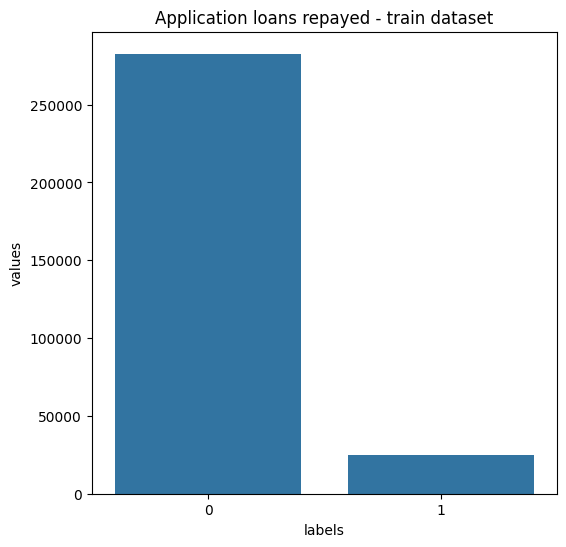

In [99]:
temp = df_train["target"].value_counts()
df = pd.DataFrame({'labels': temp.index,
                   'values': temp.values
                  })
plt.figure(figsize = (6,6))
plt.title('Application loans repayed - train dataset')
sns.set_color_codes("pastel")
sns.barplot(x = 'labels', y="values", data=df)
locs, labels = plt.xticks()
plt.show()

Теперь, давайте посмотрим сколько же у нас категориальных фичей и сколько числовых

In [109]:
aux = ['sk_id_curr']  # Вспомогательный список с колонной, которую нужно исключить
target = ['target']  # Целевая переменная
categ = [col for col in df_train.columns if col not in (aux + target) and df_train[col].nunique() <= 7] + \
        [col for col in df_train.columns if col not in (aux + target) and df_train[col].dtypes == np.dtype('O')]
categ = list(set(categ))

nums = [col for col in df_train.columns if col not in (categ + target + aux)]

# Вывод количества категориальных и числовых переменных
print(f"Список категориальных переменных: {len(categ)}")
print(f"Список числовых переменных: {len(nums)}")

Список категориальных переменных: 51
Список числовых переменных: 69


Сейчас давайте посмотрим, что представляют из себя данные из бюро 

In [35]:
bureau.head()

,sk_id_curr,sk_id_bureau,credit_active,credit_currency,days_credit,credit_day_overdue,days_credit_enddate,days_enddate_fact,amt_credit_max_overdue,cnt_credit_prolong,amt_credit_sum,amt_credit_sum_debt,amt_credit_sum_limit,amt_credit_sum_overdue,credit_type,days_credit_update,amt_annuity
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,


In [36]:
bureau.columns.values

array(['sk_id_curr', 'sk_id_bureau', 'credit_active', 'credit_currency',
       'days_credit', 'credit_day_overdue', 'days_credit_enddate',
       'days_enddate_fact', 'amt_credit_max_overdue',
       'cnt_credit_prolong', 'amt_credit_sum', 'amt_credit_sum_debt',
       'amt_credit_sum_limit', 'amt_credit_sum_overdue', 'credit_type',
       'days_credit_update', 'amt_annuity'], dtype=object)

Определим сколько у нас пропусков

## Check none

In [102]:
def missing_data(data: pd.DataFrame) -> pd.DataFrame:
    total = data.isnull().sum().sort_values(ascending=False)
    percent = (data.isnull().sum() / data.isnull().count() * 100).sort_values(ascending=False)
    return pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])


In [103]:
missing_data(df_train)

,Total,Percent
commonarea_avg,214865,69.872297
commonarea_medi,214865,69.872297
commonarea_mode,214865,69.872297
nonlivingapartments_mode,213514,69.432963
nonlivingapartments_avg,213514,69.432963
...,...,...
name_income_type,0,0.000000
name_type_suite,0,0.000000
amt_credit,0,0.000000
fondkapremont_mode,0,0.000000


In [105]:
missing_data(df_test)

,Total,Percent
commonarea_medi,33495,68.716150
commonarea_mode,33495,68.716150
commonarea_avg,33495,68.716150
nonlivingapartments_avg,33347,68.412523
nonlivingapartments_mode,33347,68.412523
...,...,...
name_education_type,0,0.000000
name_income_type,0,0.000000
name_type_suite,0,0.000000
amt_goods_price,0,0.000000


In [104]:
missing_data(bureau)

,Total,Percent
amt_credit_max_overdue,1124488,65.513264
days_enddate_fact,633653,36.916958
amt_credit_sum_limit,591780,34.477415
amt_credit_sum_debt,257669,15.011932
days_credit_enddate,105553,6.149573
...,...,...
credit_day_overdue,0,0.000000
days_credit,0,0.000000
credit_currency,0,0.000000
credit_active,0,0.000000


# Research

In [183]:
def plot_stats(feature: str, label_rotation: bool = False, horizontal_layout: bool = True) -> None:
    feature = feature.lower()
    temp = df_train[feature].value_counts()
    df1 = pd.DataFrame({feature: temp.index, 'Number of contracts': temp.values})

    # Calculate the percentage of target=1 per category value
    cat_perc = df_train[[feature, 'target']].groupby([feature], as_index=False).mean()
    cat_perc.sort_values(by='target', ascending=False, inplace=True)

    if horizontal_layout:
        fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))
    else:
        fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(12, 14))
    sns.set_color_codes("pastel")
    
    # Первый график: количество контрактов по категориям
    sns.barplot(ax=ax1, x=feature, y="Number of contracts", data=df1, 
                        hue=feature, palette='Set2', legend=False)
    if label_rotation:
        ax1.set_xticks(ax1.get_xticks())  # Устанавливаем метки оси x
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)  # Поворачиваем метки

    # Второй график: процент target=1 по категориям
    sns.barplot(ax=ax2, x=feature, y='target', order=cat_perc[feature], 
                    data=cat_perc, hue=feature, palette='Set2', legend=False)
    if label_rotation:
        ax2.set_xticks(ax2.get_xticks())  # Устанавливаем метки оси x
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)  # Поворачиваем метки

    ax2.set_ylabel('Percent of target with value 1 [%]', fontsize=10)
    plt.tick_params(axis='both', which='major', labelsize=10)

    plt.show()


## Application 

А теперь давайте расссмотрим данные более детально

Посмотрим имя контрактов

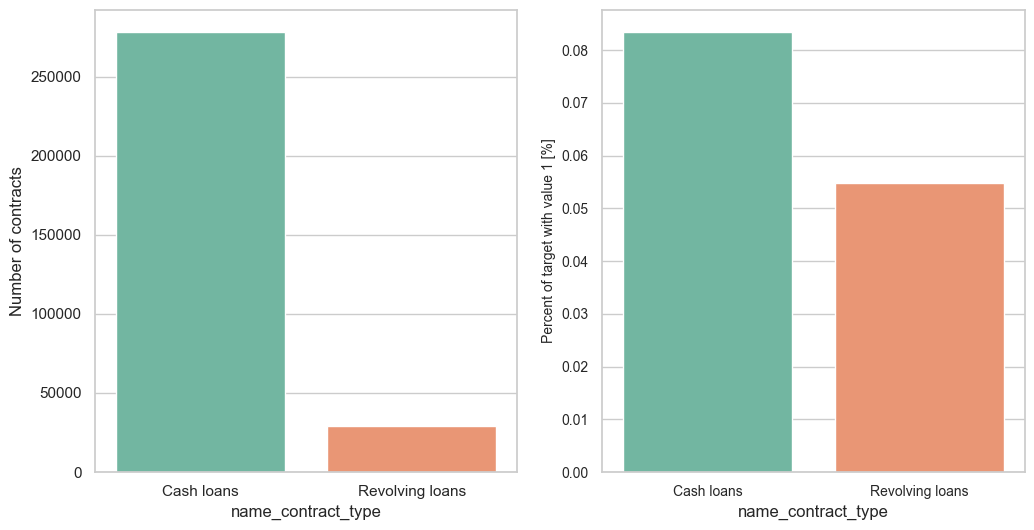

In [184]:
plot_stats('name_contract_type')

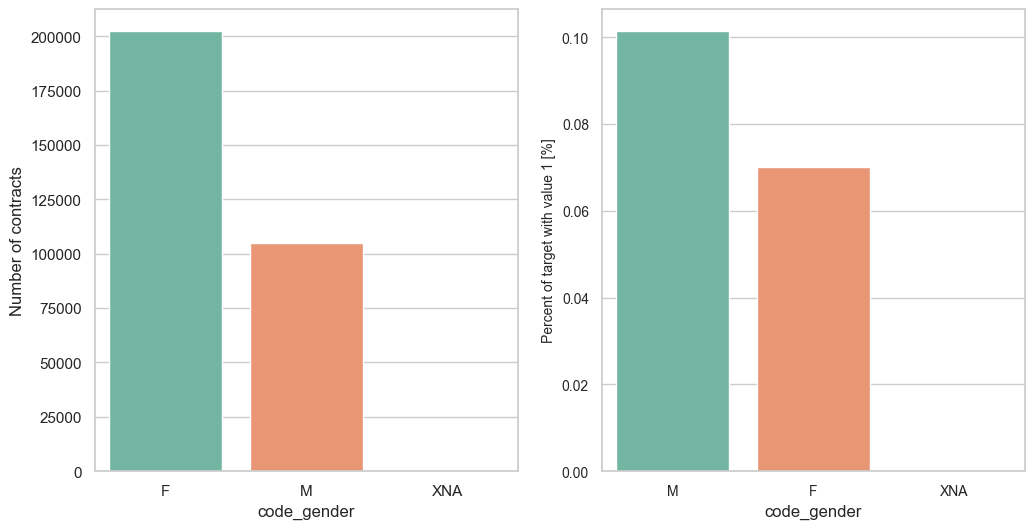

In [185]:
plot_stats('code_gender')

Интересно, что женщины занимают больше денег, и более пунктуальны нежели мужчины)

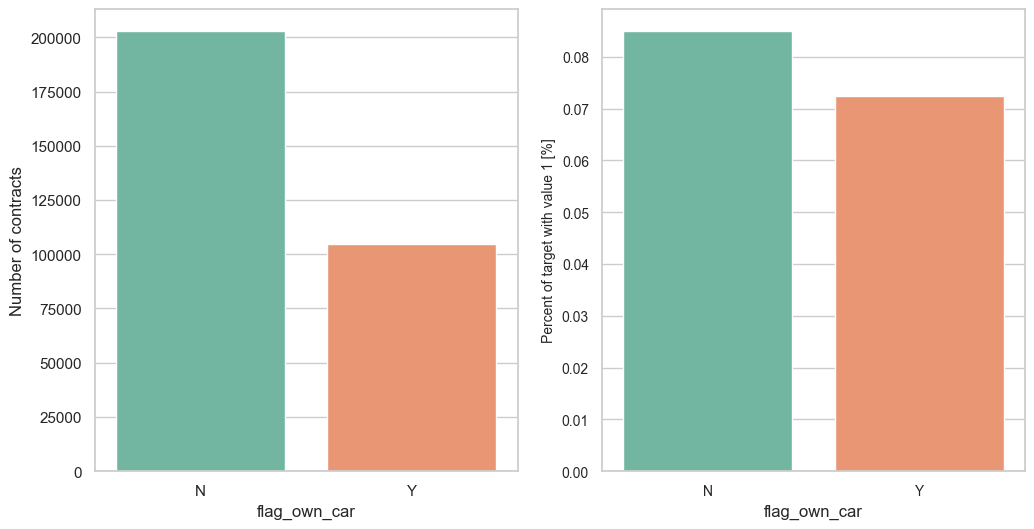

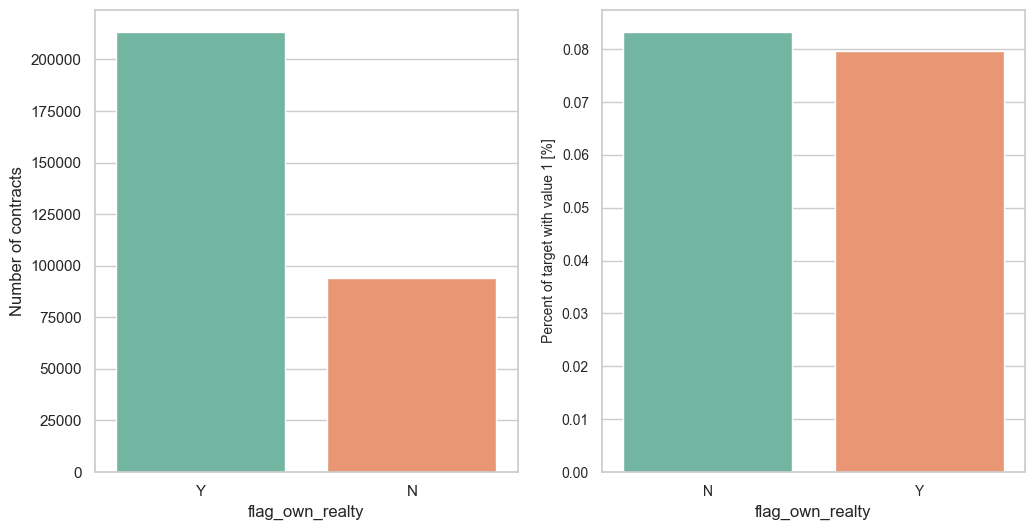

In [186]:
plot_stats('FLAG_OWN_CAR')
plot_stats('FLAG_OWN_REALTY')

In [106]:
df_description[df_description['row'] == 'FLAG_OWN_REALTY'].description

5    Flag if client owns a house or flat
Name: description, dtype: object

Отсюда можно сделать вывод, что люди, владеющие собЁственностью - более дисциплинированные, нежели остальные

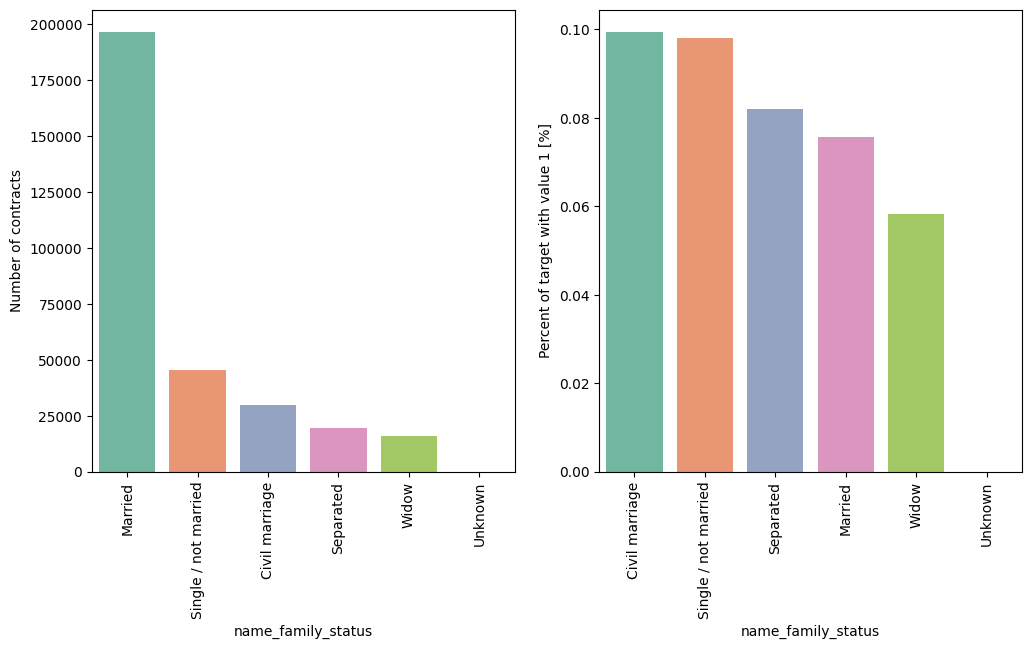

In [46]:
plot_stats('NAME_FAMILY_STATUS', True, True)

Из этих данных можно сделать вывод, что люди, которые более ответсвенно относятся к своей личной жизни - также отвественны в финансовом плане


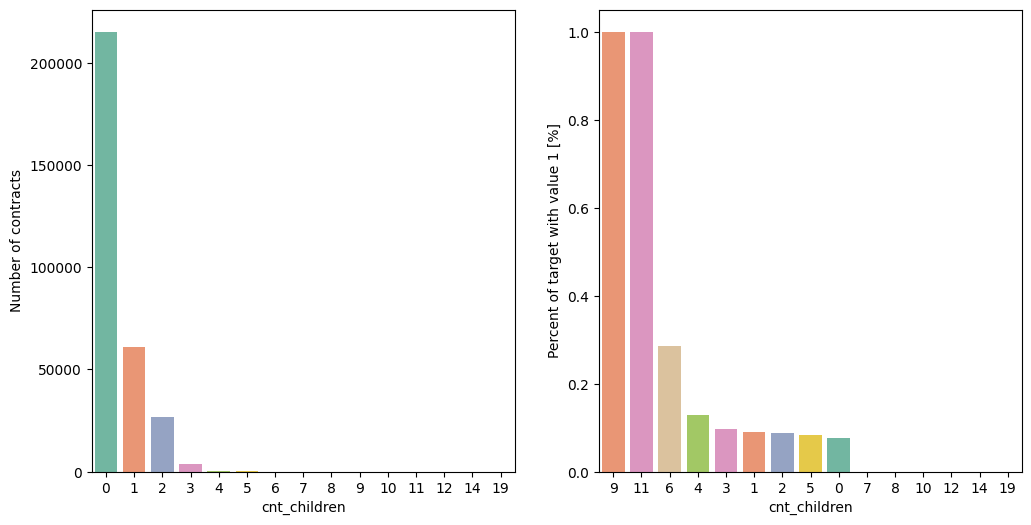

In [47]:
plot_stats('CNT_CHILDREN')

Рискну предположить, что те у кого мало детей или нет соввсем - та категория людей, которая начинает жизнь и им нужны деньги на покупку новых вещей(тостеры, стиральные машинки и так далее). Огромный процент проблемных клиентов в больших семьях - пологаю, что люди, которые безотвественно рожают(отсутсвие планирования семьи) - также влиет на финансовую ответсвтенность 

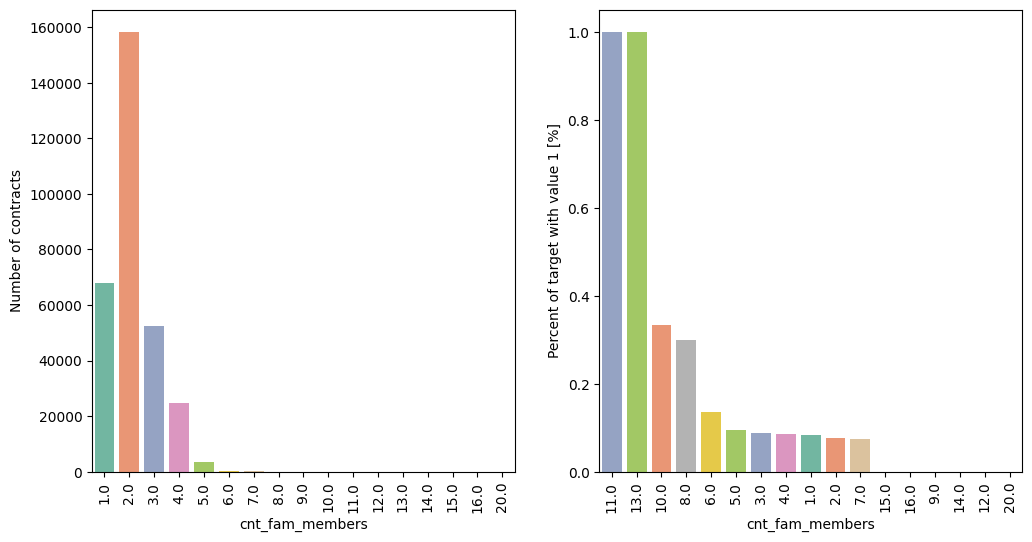

In [48]:
plot_stats('CNT_FAM_MEMBERS',True)

In [108]:
df_description[df_description['row'] == 'OCCUPATION_TYPE'].description

28    What kind of occupation does the client have
Name: description, dtype: object

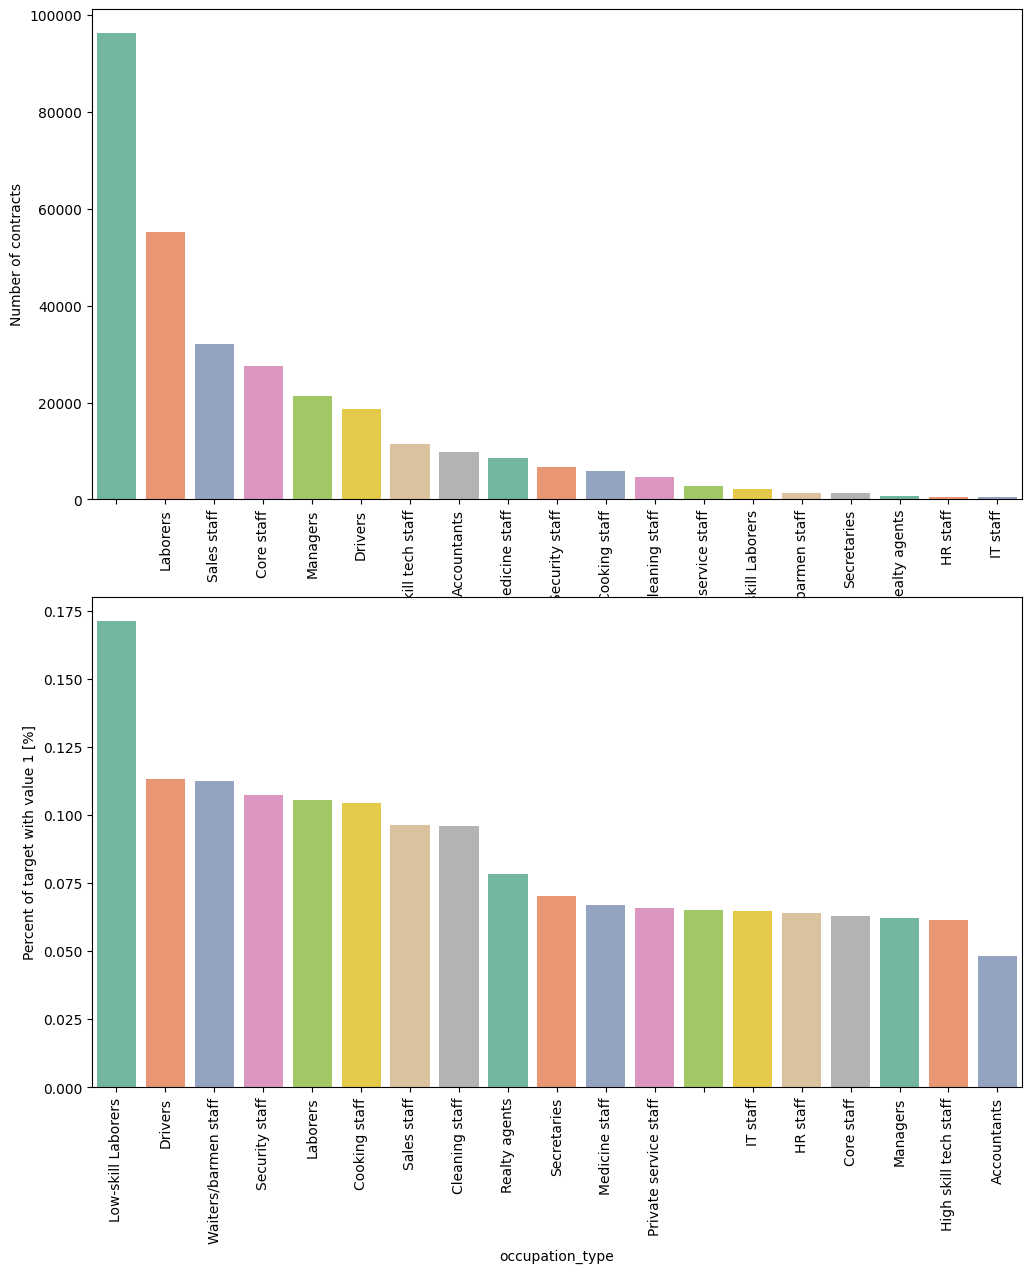

In [49]:
plot_stats('OCCUPATION_TYPE'.lower(),True, False)

Как видно из графика - уровень квалификации напрямую зависит от того нужны ли вам деньги(наверное высокооплачиваемые специалисты не нуждаются в долгах)

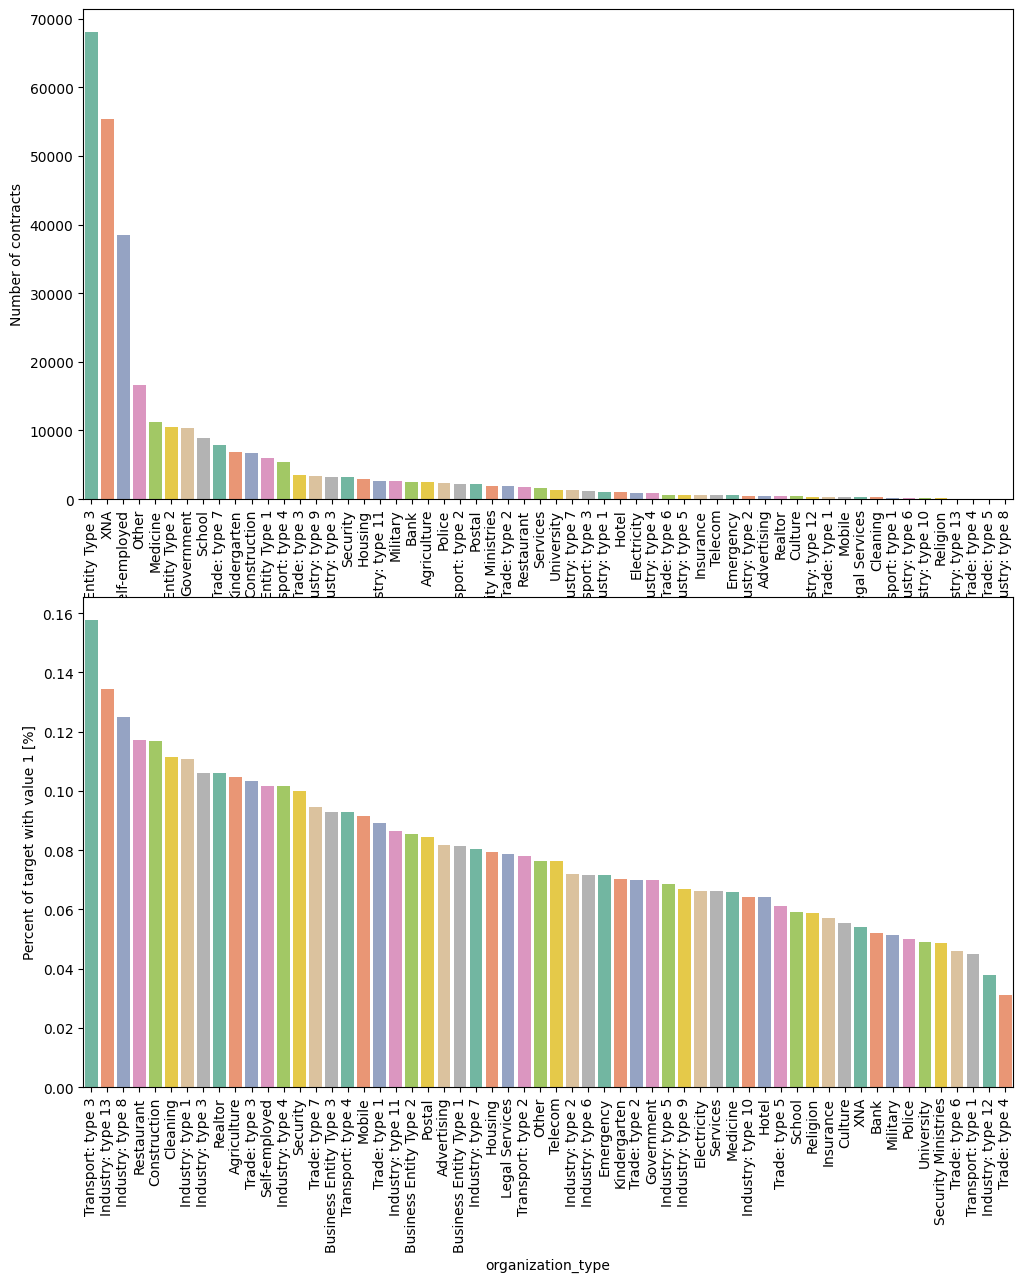

In [50]:
plot_stats('ORGANIZATION_TYPE',True, False)

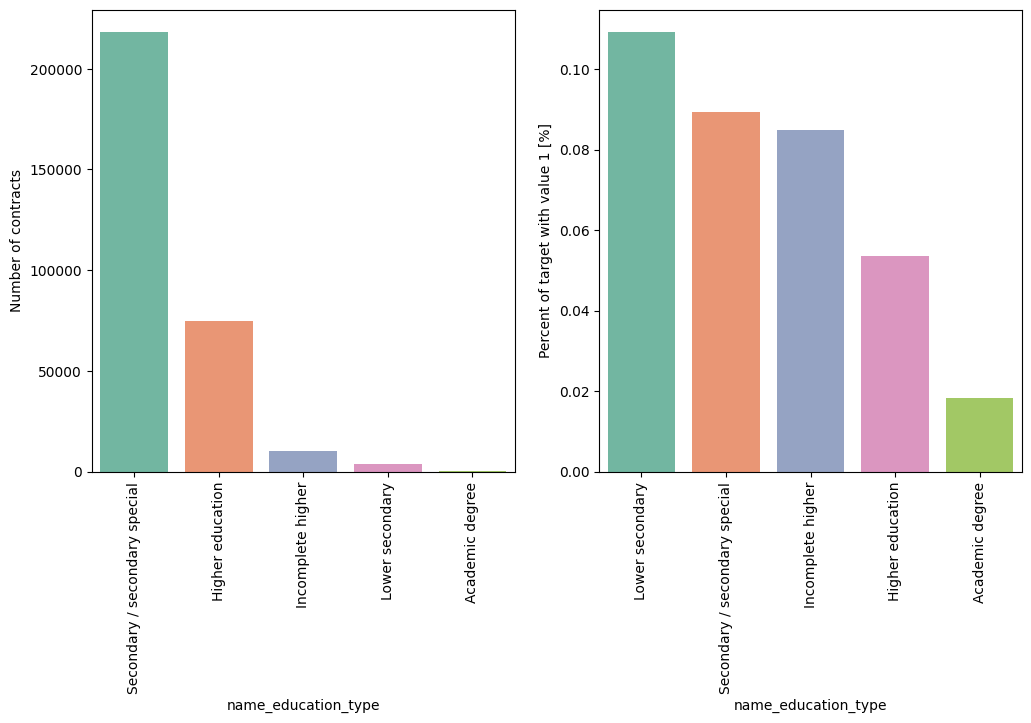

In [51]:
plot_stats('NAME_EDUCATION_TYPE', True)

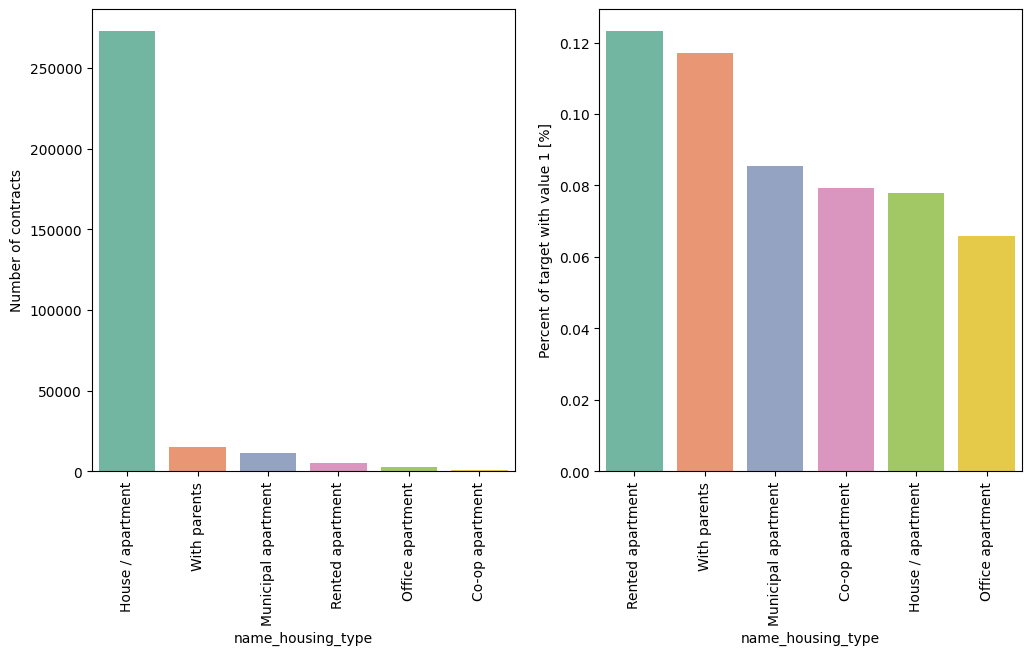

In [52]:
plot_stats('NAME_HOUSING_TYPE', True)

Этот график также подтверждает тезис выше, что владеющие собственностью люди - более отвественны 

In [109]:
def plot_distribution(feature: str, color: str) -> None:
    feature = feature.lower()
    plt.figure(figsize=(10,6))
    plt.title("Distribution of %s" % feature)
    
    # Используем histplot вместо distplot
    sns.histplot(df_train[feature].dropna(), color=color, kde=True, bins=100)
    
    plt.show()

In [110]:
# def plot_distribution_comp(var,nrow=2):
#     i = 0
#     t1 = df_train.loc[application_train['TARGET'] != 0]
#     t0 = df_train.loc[application_train['TARGET'] == 0]

#     sns.set_style('whitegrid')
#     plt.figure()
#     fig, ax = plt.subplots(nrow,2,figsize=(12,6*nrow))

#     for feature in var:
#         i += 1
#         plt.subplot(nrow,2,i)
#         sns.kdeplot(t1[feature], bw=0.5,label="TARGET = 1")
#         sns.kdeplot(t0[feature], bw=0.5,label="TARGET = 0")
#         plt.ylabel('Density plot', fontsize=12)
#         plt.xlabel(feature, fontsize=12)
#         locs, labels = plt.xticks()
#         plt.tick_params(axis='both', which='major', labelsize=12)
#     plt.show();

А тут давайте посмотрим на распределения 

In [112]:
df_description[df_description['row'] == 'AMT_INCOME_TOTAL'].description

7    Income of the client
Name: description, dtype: object

In [117]:
df_train.amt_income_total.value_counts()

amt_income_total
135000.0    35750
112500.0    31019
157500.0    26556
180000.0    24719
90000.0     22483
            ...  
97731.0         1
337545.0        1
53140.5         1
657000.0        1
175698.0        1
Name: count, Length: 2548, dtype: int64

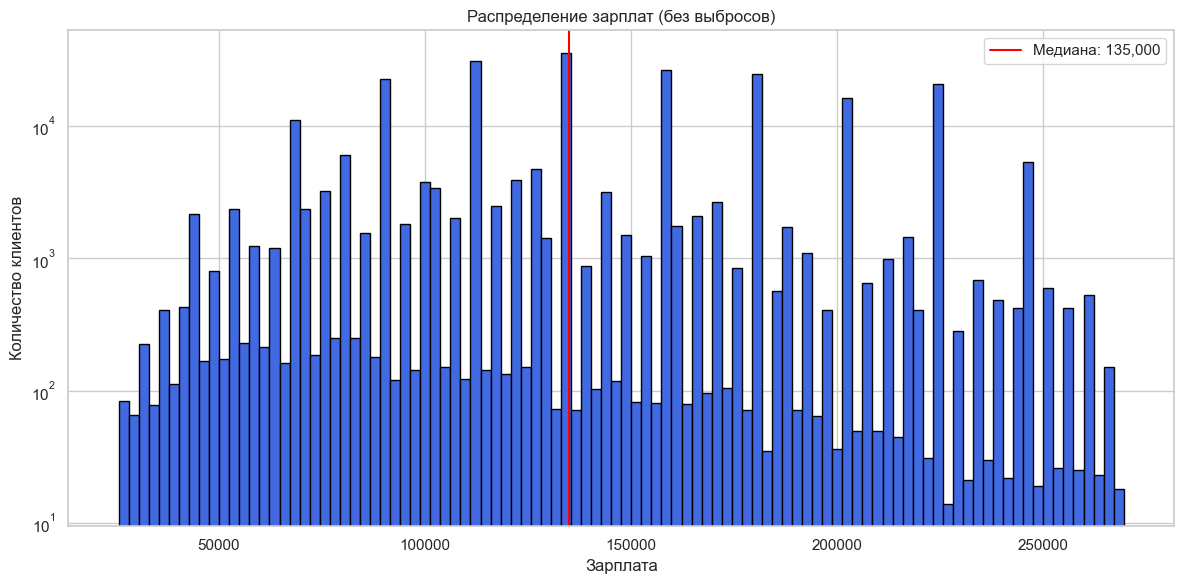

In [154]:
# Обрезаем выбросы (например, выше 99-го процентиля)
q99 = df_train['amt_income_total'].quantile(0.90)
filtered = df_train[df_train['amt_income_total'] < q99]['amt_income_total']

# Медиана новой выборки
median_filtered = np.median(filtered)

# Строим график
plt.figure(figsize=(12, 6))
plt.hist(filtered, bins=100, color='royalblue', edgecolor='black')
plt.axvline(median_filtered, color='red', linestyle='-', label=f'Медиана: {median_filtered:,.0f}')
plt.yscale('log')
plt.xlabel('Зарплата')
plt.ylabel('Количество клиентов')
plt.title('Распределение зарплат (без выбросов)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Вообще, судя по данным из интернета - банк европейский, но средняя зарплата в 135 тысяч - немного настораживает, скорее всего это условные единицы

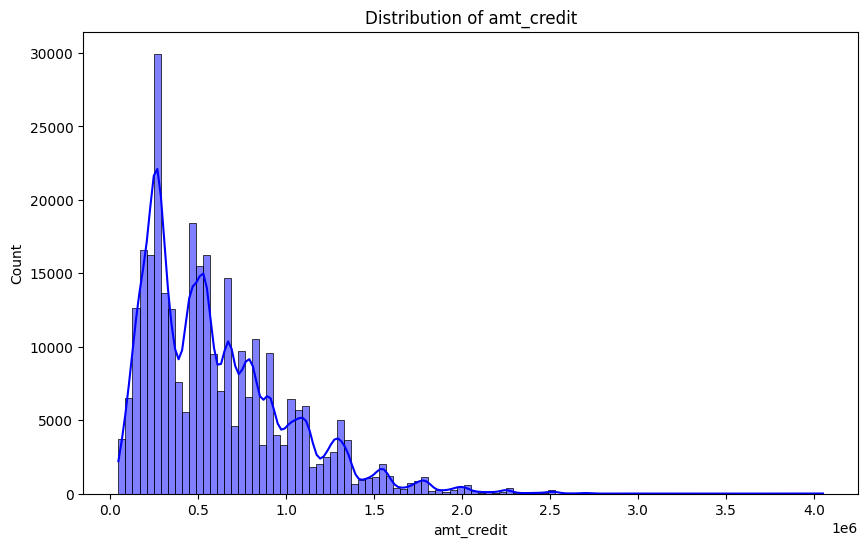

In [60]:
plot_distribution('AMT_CREDIT','blue')

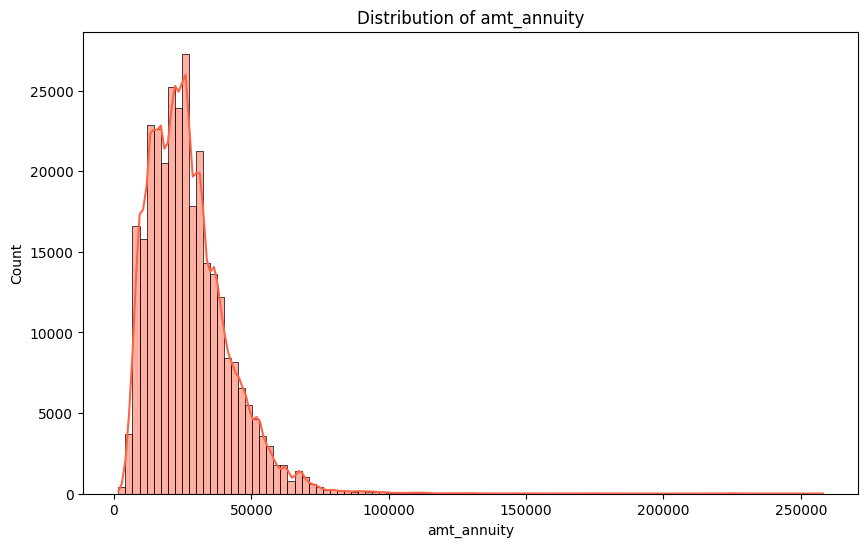

In [61]:
plot_distribution('AMT_ANNUITY','tomato')

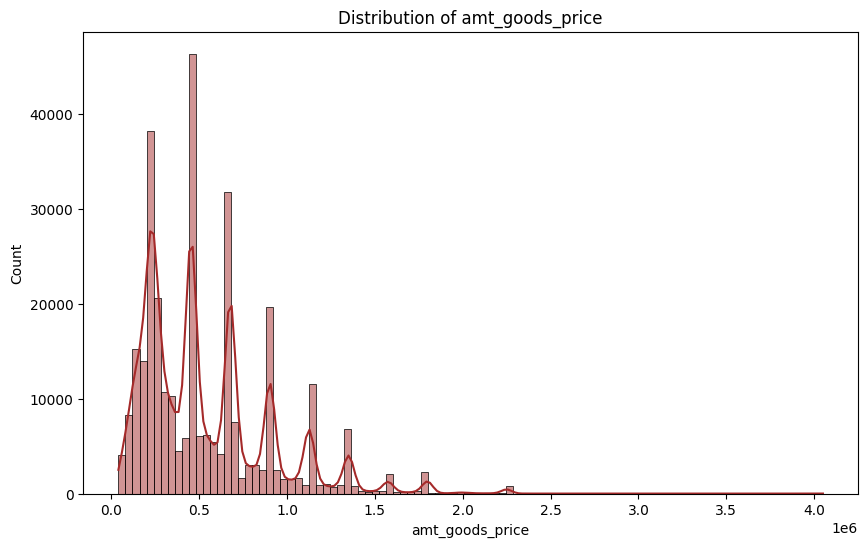

In [62]:
plot_distribution('AMT_GOODS_PRICE','brown')

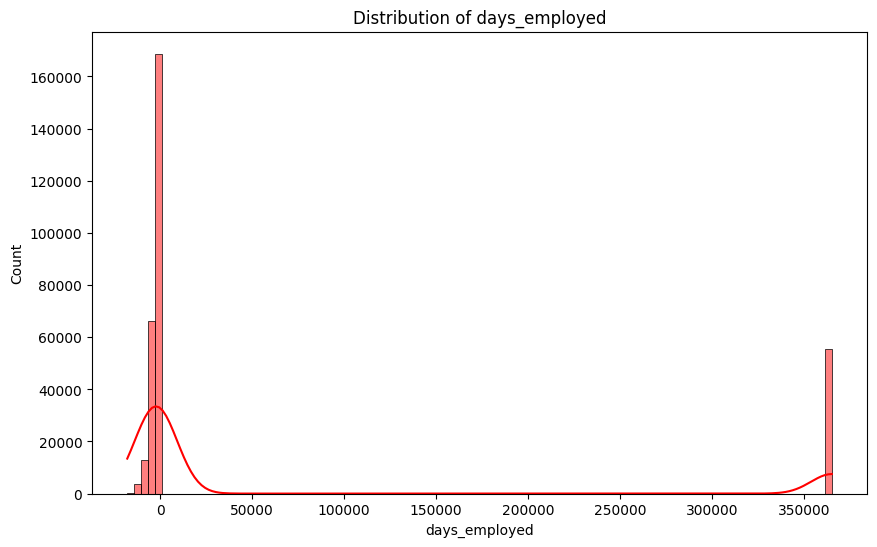

In [63]:
plot_distribution('DAYS_EMPLOYED','red')

Этот график меня вообще поразил, значения либо отрицательные, либо люди работают больше 100 лет. Видимо есть ошибка 

In [64]:
df_train.days_employed.value_counts()

days_employed
 365243    55374
-200         156
-224         152
-199         151
-230         151
           ...  
-13715         1
-15477         1
-9565          1
-16358         1
-12422         1
Name: count, Length: 12574, dtype: int64

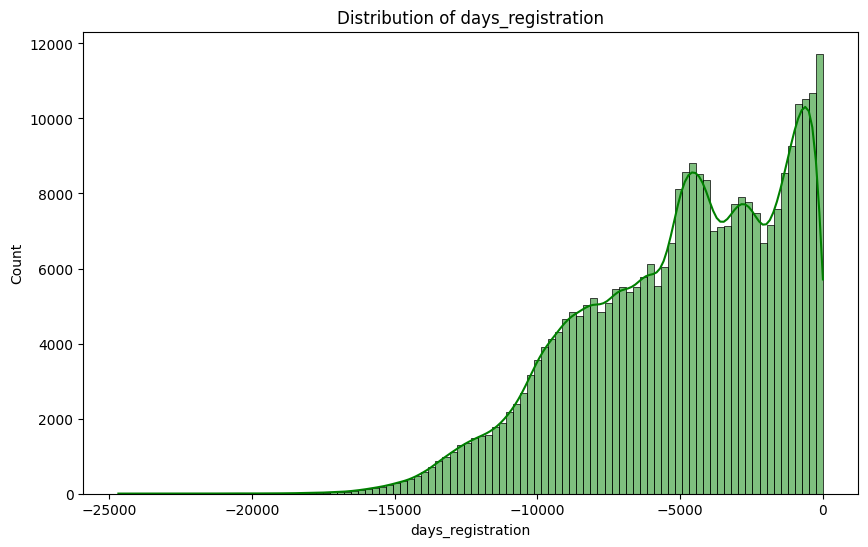

In [65]:
plot_distribution('DAYS_REGISTRATION','green')

In [155]:
df_description[df_description['row'] == 'DAYS_REGISTRATION'].description

19    How many days before the application did client change his registration
Name: description, dtype: object

Тут наверное просто ошибка со знаком

In [66]:
df_train.days_registration.value_counts()

days_registration
-1.0        113
-7.0         98
-6.0         96
-4.0         92
-2.0         92
           ... 
-15973.0      1
-17634.0      1
-19040.0      1
-15811.0      1
-14231.0      1
Name: count, Length: 15688, dtype: int64

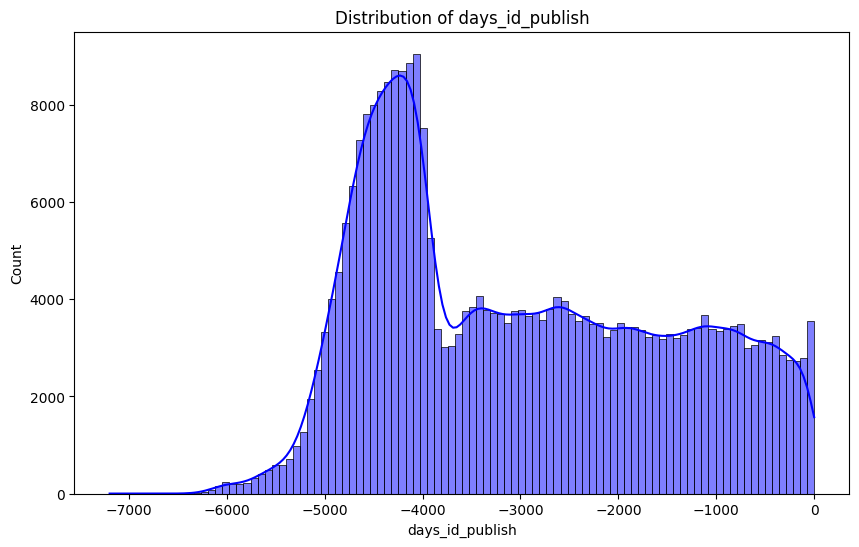

In [67]:
plot_distribution('DAYS_ID_PUBLISH','blue')

In [101]:
df_description[df_description['row'] == 'DAYS_ID_PUBLISH'].description


20    How many days before the application did client change the identity document with which he applied for the loan
Name: description, dtype: object

In [103]:
df_description[df_description['row'] == 'REG_CITY_NOT_LIVE_CITY'].description

37    Flag if client's permanent address does not match contact address (1=different, 0=same, at city level)
Name: description, dtype: object

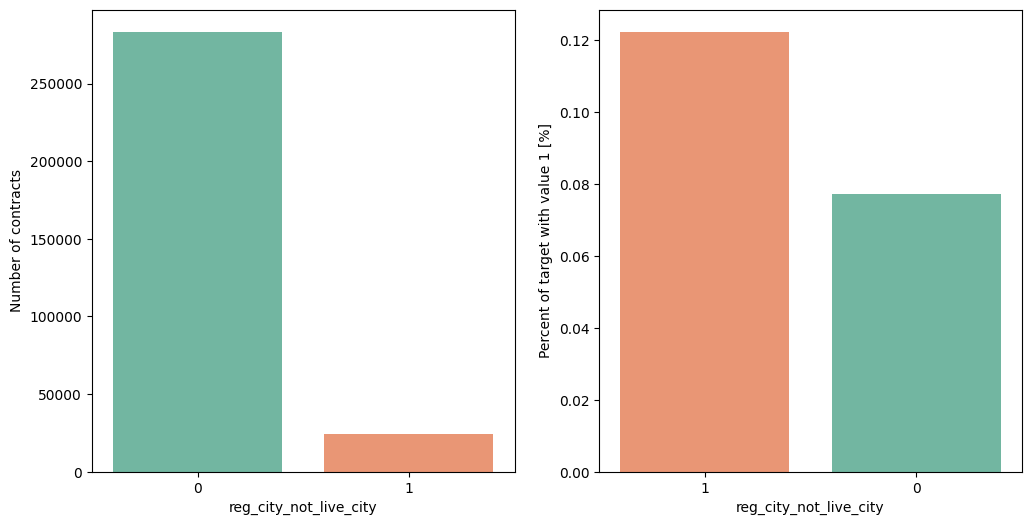

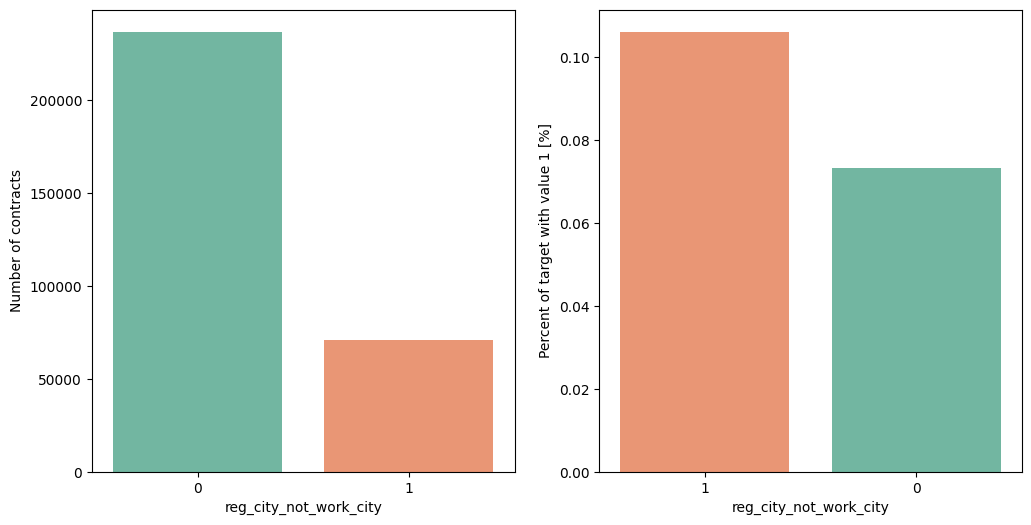

In [104]:
plot_stats('REG_CITY_NOT_LIVE_CITY')
plot_stats('REG_CITY_NOT_WORK_CITY')


Тут, вероятно, люди которые живут не на месте прописки, заранее имеют либо злой умысел, чтобы не вернуть кредит, либо же какой-то еще фактор

## Bureau

Теперь давайте посмотрим на данные из бюро 

In [107]:
bureau.columns


Index(['sk_id_curr', 'sk_id_bureau', 'credit_active', 'credit_currency',
       'days_credit', 'credit_day_overdue', 'days_credit_enddate',
       'days_enddate_fact', 'amt_credit_max_overdue', 'cnt_credit_prolong',
       'amt_credit_sum', 'amt_credit_sum_debt', 'amt_credit_sum_limit',
       'amt_credit_sum_overdue', 'credit_type', 'days_credit_update',
       'amt_annuity'],
      dtype='object')

In [108]:
df_description[df_description['row'] == 'CREDIT_ACTIVE']

,column1,table,row,description,special
129,127,bureau.csv,CREDIT_ACTIVE,Status of the Credit Bureau (CB) reported credits,


In [11]:
application_bureau_train = df_train.merge(bureau, left_on='SK_ID_CURR'.lower(), right_on='SK_ID_CURR'.lower(), how='inner')

In [14]:
print("The resulting dataframe `application_bureau_train` has ",application_bureau_train.shape[0]," rows and ", 
      application_bureau_train.shape[1]," columns.")


The resulting dataframe `application_bureau_train` has  1465325  rows and  138  columns.


Сделаем слияние двух таблиц, чтобы можно было отслеживать корреляцию с таргетом 

In [30]:
def plot_b_stats(feature: str, label_rotation: bool = False, horizontal_layout: bool = True) -> None:
    feature = feature.lower()
    temp = application_bureau_train[feature].value_counts()
    df1 = pd.DataFrame({feature: temp.index, 'Number of contracts': temp.values})
    cat_perc = application_bureau_train[[feature, 'target']].groupby([feature], as_index=False).mean()
    cat_perc.sort_values(by='target', ascending=False, inplace=True)
    if horizontal_layout:
        fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 6))
    else:
        fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(12, 14))
    sns.barplot(ax=ax1, x=feature, y="Number of contracts", data=df1,
                hue=feature, palette="Set1", dodge=False)
    if label_rotation:
        ax1.set_xticks(ax1.get_xticks())  # Явно устанавливаем метки на оси
        ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)  # Поворачиваем метки
    sns.barplot(ax=ax2, x=feature, y='target', order=cat_perc[feature], data=cat_perc,
                hue=feature, palette="Set2", dodge=False)
    if label_rotation:
        ax2.set_xticks(ax2.get_xticks())  # Явно устанавливаем метки на оси
        ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)  # Поворачиваем метки
    ax2.set_ylabel('Percent of target with value 1 [%]', fontsize=10)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.show()

In [37]:
def plot_b_distribution(feature: str, color: str) -> None:
    feature = feature.lower()
    plt.figure(figsize=(10, 6))
    plt.title("Distribution of %s" % feature)
    sns.histplot(application_bureau_train[feature].dropna(), color=color, kde=True, bins=100)
    plt.show()

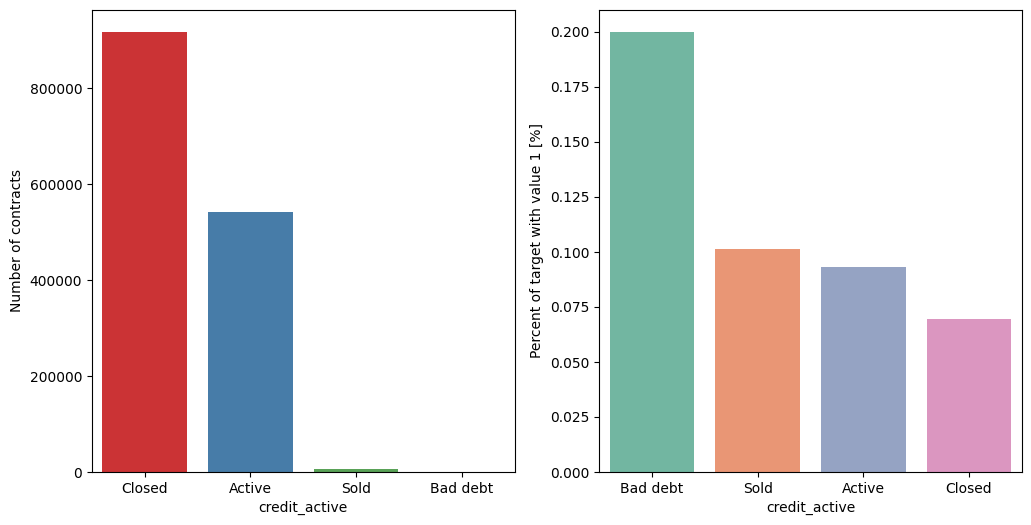

In [31]:
plot_b_stats('CREDIT_ACTIVE')

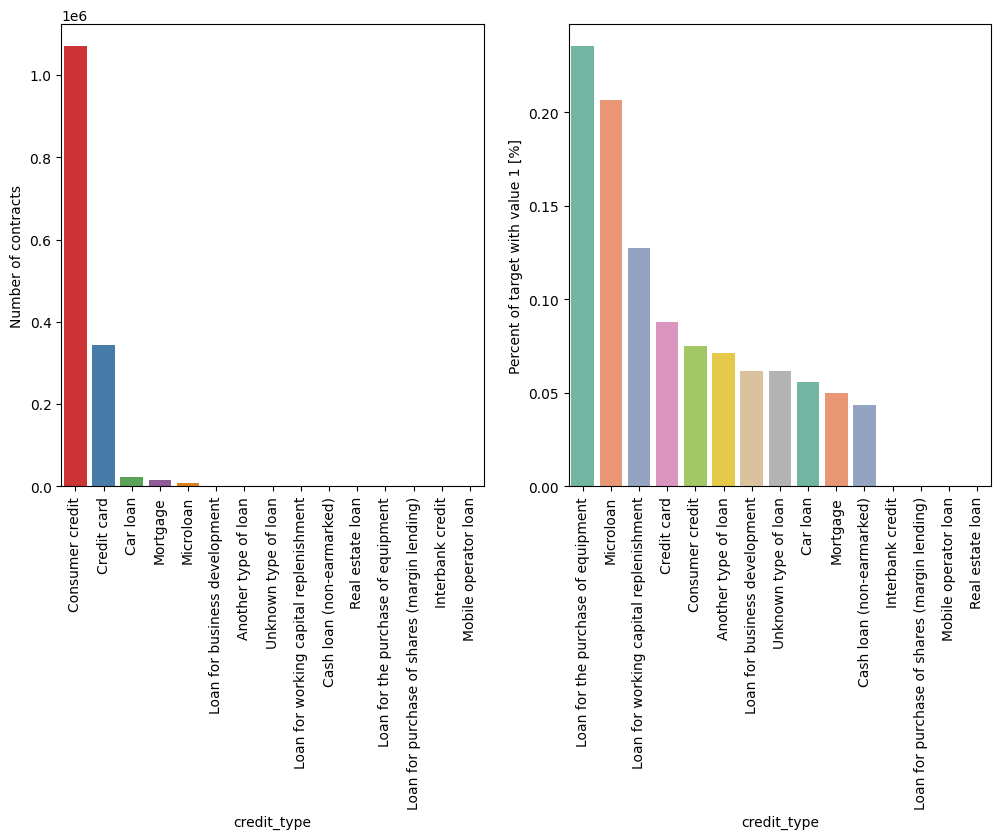

In [32]:
plot_b_stats('CREDIT_TYPE', True, True)

Отсюда видно - что большинство кредитов - потребительские(хотят купить посудомойки, фены, все из этой области)

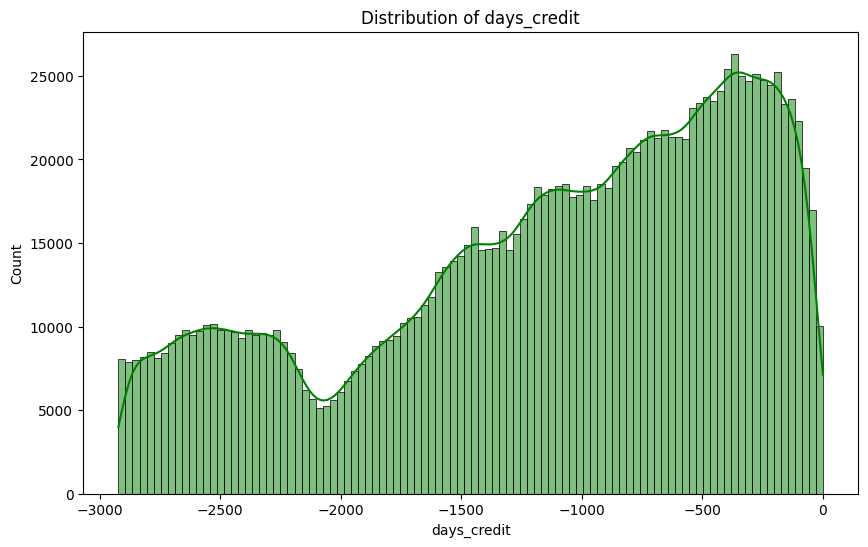

In [38]:
plot_b_distribution('DAYS_CREDIT','green')

Тут вероятно тоже что-то не так со знаком 

In [156]:
df_description[df_description['row'] == 'CREDIT_DAY_OVERDUE']

,column1,table,row,description,special
132,130,bureau.csv,CREDIT_DAY_OVERDUE,Number of days past due on CB credit at the time of application for related loan in our sample,


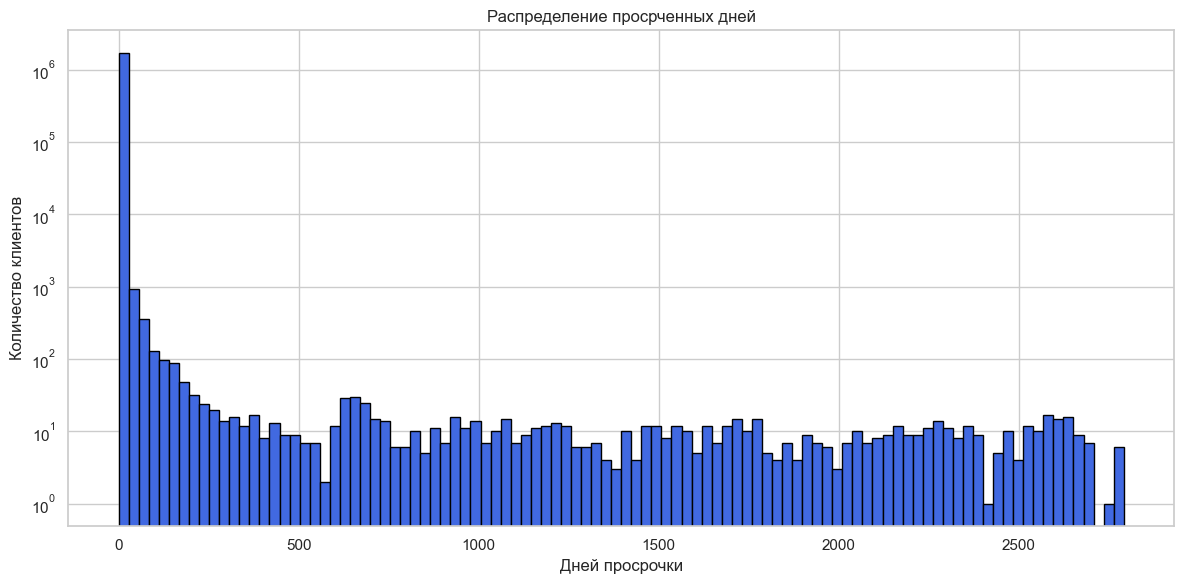

In [168]:

# Строим график
plt.figure(figsize=(12, 6))
plt.hist(bureau['CREDIT_DAY_OVERDUE'.lower()], bins=100, color='royalblue', edgecolor='black')

plt.yscale('log')
plt.xlabel('Дней просрочки')
plt.ylabel('Количество клиентов')
plt.title('Распределение просрченных дней')

plt.grid(True)
plt.tight_layout()
plt.show()

In [161]:
bureau.credit_day_overdue.value_counts()

credit_day_overdue
0       1712211
30          311
60          126
8           103
13          103
         ...   
1445          1
278           1
707           1
2193          1
1931          1
Name: count, Length: 942, dtype: int64

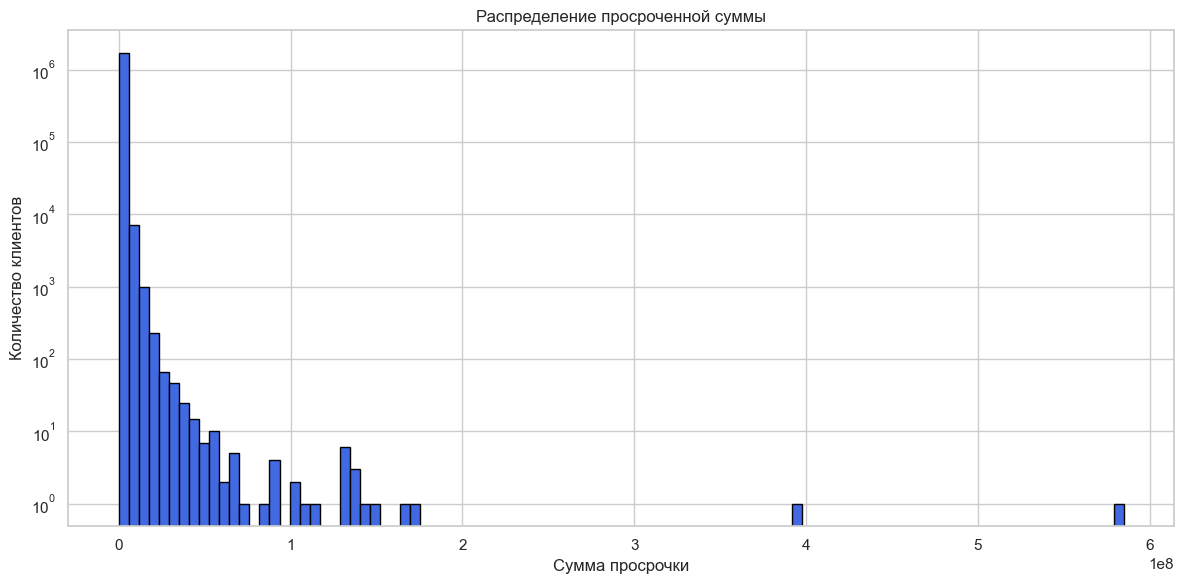

In [171]:
# Строим график
plt.figure(figsize=(12, 6))
plt.hist(bureau['amt_credit_sum'.lower()], bins=100, color='royalblue', edgecolor='black')
plt.yscale('log')
plt.xlabel('Сумма просрочки')
plt.ylabel('Количество клиентов')
plt.title('Распределение просроченной суммы')

plt.grid(True)
plt.tight_layout()
plt.show()